<a href="https://colab.research.google.com/github/harshitt018/Advance-Data-Science/blob/main/Autoencoders_using_MNIST_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing Libraries**

In [ ]:
import keras
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras
from tensorflow.keras import backend as k

%matplotlib inline

from keras.datasets import mnist
from keras.models import Model
from tensorflow.keras.layers import Input, add, Layer, Dense, Dropout, Activation, Flatten, Reshape

from keras import regularizers
from keras.regularizers import l2
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, ZeroPadding2D
from tensorflow.keras.utils import to_categorical

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

Normalization

In [ ]:
X_train = X_train.astype('float32')/255.
X_test = X_test.astype('float32')/255.

print('X_train Shape: ', X_train.shape)
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

X_train Shape:  (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [ ]:
X_train = X_train.reshape((len(X_train)), np.prod(X_train.shape[1:]))
X_test = X_test.reshape((len(X_test)), np.prod(X_test.shape[1:]))

In [ ]:
input_size = 784
hidden_size = 64
output_size = 784

x = Input(shape=(input_size,))
h= Dense(hidden_size, activation='relu')(x)
r= Dense(output_size, activation='sigmoid')(h)

autoencoder = Model(inputs=x, outputs=r)
autoencoder.compile(optimizer='adam', loss='mse')

In [ ]:
epochs = 50
bs = 128

history = autoencoder.fit(X_train, X_train, batch_size=bs, epochs=epochs, verbose = 1,  validation_data=(X_test, X_test))

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0734 - val_loss: 0.0218
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0192 - val_loss: 0.0126
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0116 - val_loss: 0.0085
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0082 - val_loss: 0.0066
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0064 - val_loss: 0.0055
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0055 - val_loss: 0.0049
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0050 - val_loss: 0.0046
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0047 - val_loss: 0.0044
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0045 - val_loss: 0.0043
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0044 - val_loss: 0.0042
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0043 - val_loss: 0.0041
Epoch 12/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


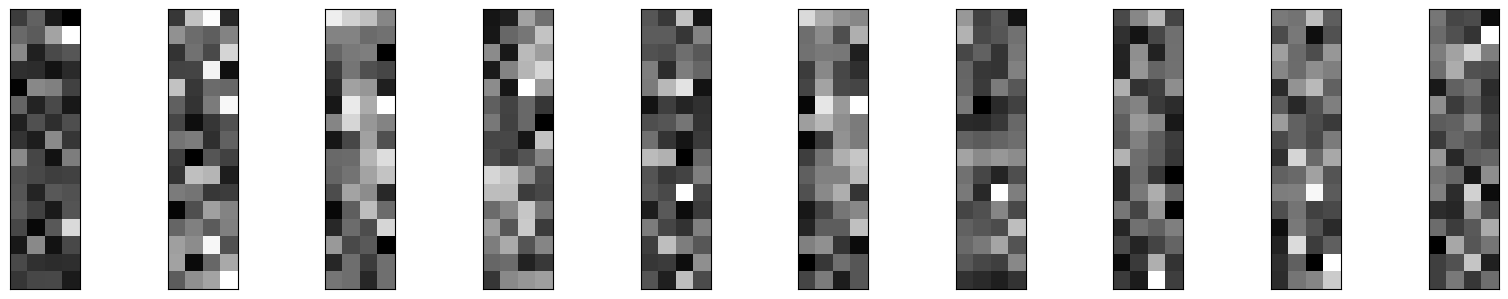

In [ ]:
conv_encoder = Model(x, h)
encoded_img = conv_encoder.predict(X_test)

n=10
plt.figure(figsize=(20, 8))
for i in range(n):
  ax = plt.subplot(2, n, i+1)
  plt.imshow(encoded_img[i].reshape(4, 16).T)
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

plt.show()

In [ ]:
decoded_imgs = autoencoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


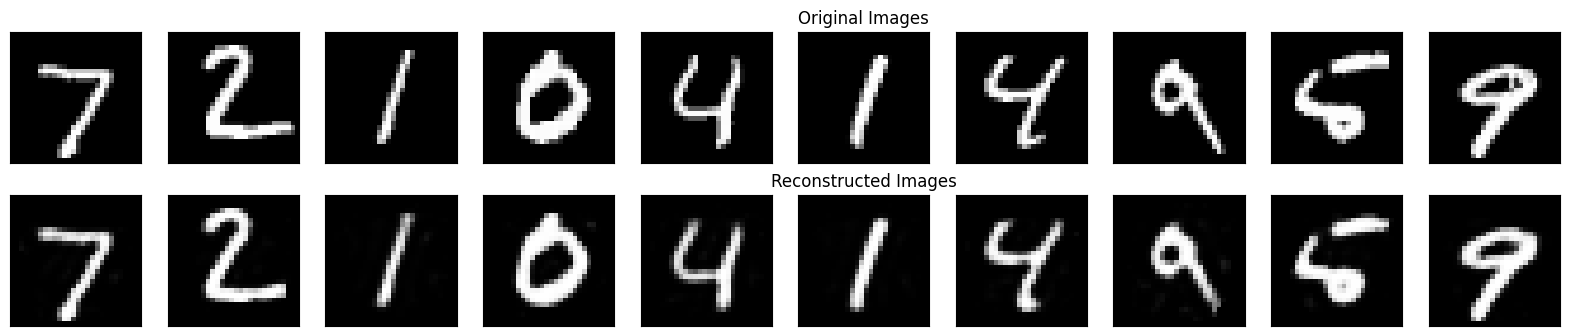

In [ ]:
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
  ax = plt.subplot(3, n, i+1)
  plt.imshow(X_test[i].reshape(28, 28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
  if i == n/2:
    ax.set_title('Original Images')

  ax = plt.subplot(3, n, i+1+n)
  plt.imshow(decoded_imgs[i].reshape(28, 28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
  if i == n/2:
    ax.set_title('Reconstructed Images')

plt.show()

dict_keys(['loss', 'val_loss'])


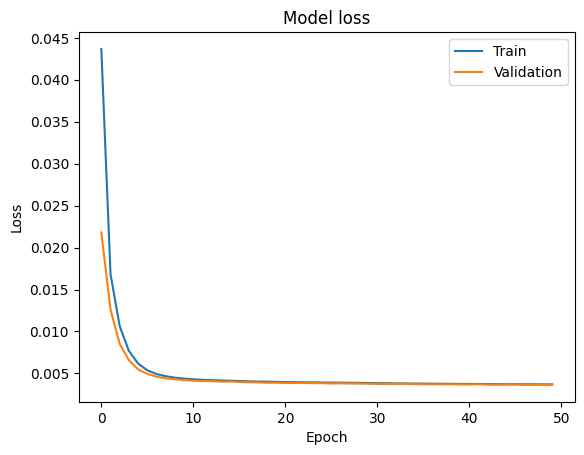

In [ ]:
print(history.history.keys())

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()